In [953]:
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
from data_V import N_points, V0_L, mL, StaticV
# import lib_plot


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Eigenvalues = [-8.59332218 -4.6003875   0.98805764  5.96812708]


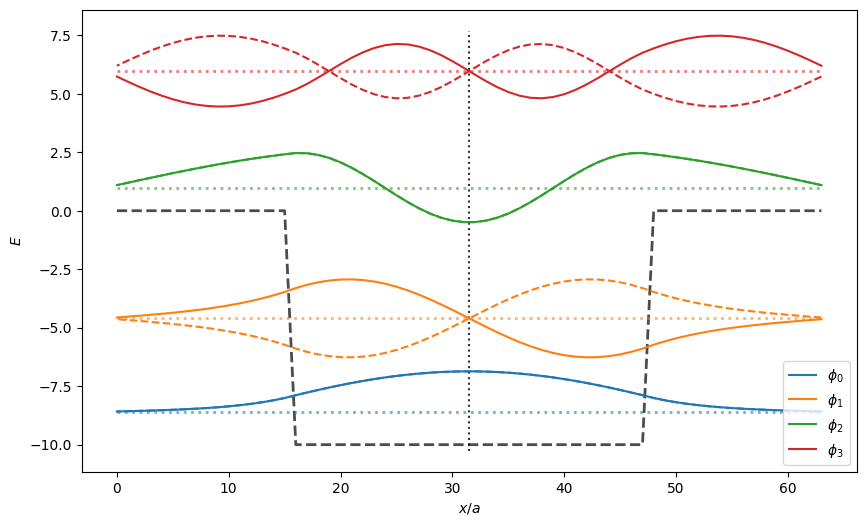

In [954]:
tot_eig_val = np.loadtxt('V_values.txt')
tot_eig_vect = np.loadtxt('V_vectors.txt')

selec = 4
eig_val = np.copy(tot_eig_val)[:selec]
eig_vect = np.copy(tot_eig_vect)[:, :selec].T

print('Eigenvalues =', eig_val)


xcoo = np.arange(0, N_points)
# cols = color_map(np.linspace(0, 1, selec))
cols = [f'C{i}' for i in range(10)]

plt.figure(figsize=(10, 6))
plt.plot(xcoo, StaticV(xcoo), color='black', ls='--', alpha=0.7, 
         lw=2)
for i, eig in enumerate(eig_val):
    plt.hlines(eig, min(xcoo), max(xcoo), color=cols[i], ls=':', alpha=0.6, lw=2)
    plt.plot(xcoo, mL*eig_vect[i] + eig, color=cols[i], zorder=2,
             label=rf'$\phi_{i}$')
    # symmetry
    plt.plot(np.flip(xcoo), mL*eig_vect[i] + eig, color=cols[i], ls='--', zorder=2)

plt.vlines(xcoo[-1]/2, np.min(eig_vect)*mL+eig_val[0], np.max(eig_vect)*mL+eig_val[-1],
           color='black', ls=':', zorder=0, alpha=0.8)

plt.xlabel(r'$x/a$')
plt.ylabel(r'$E$')
plt.legend(loc='lower right')
plt.show()

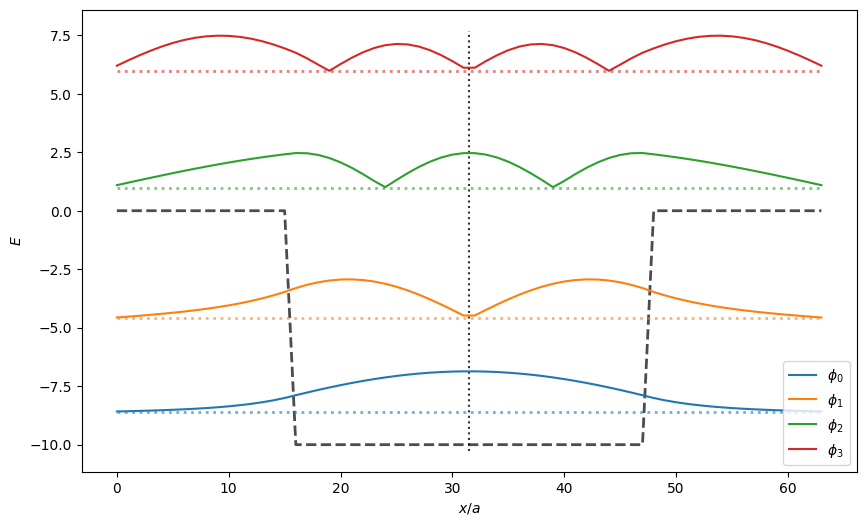

In [955]:
xcoo = np.arange(0, N_points)

plt.figure(figsize=(10, 6))
plt.plot(xcoo, StaticV(xcoo), color='black', ls='--', alpha=0.7, 
         lw=2)
for i, eig in enumerate(eig_val):
    plt.hlines(eig, min(xcoo), max(xcoo), color=cols[i], ls=':', alpha=0.6, lw=2)
    
    plt.plot(xcoo, mL*abs(eig_vect[i]) + eig, color=cols[i], zorder=2,
             label=rf'$\phi_{i}$')

plt.vlines(xcoo[-1]/2, np.min(eig_vect)*mL+eig_val[0], np.max(eig_vect)*mL+eig_val[-1],
           color='black', ls=':', zorder=0, alpha=0.8)

plt.xlabel(r'$x/a$')
plt.ylabel(r'$E$')
plt.legend(loc='lower right')
plt.show()

## **Degenerazioni**

Eigenvalues = [ 5.10305752  5.17699448 11.93181269 15.83058909]


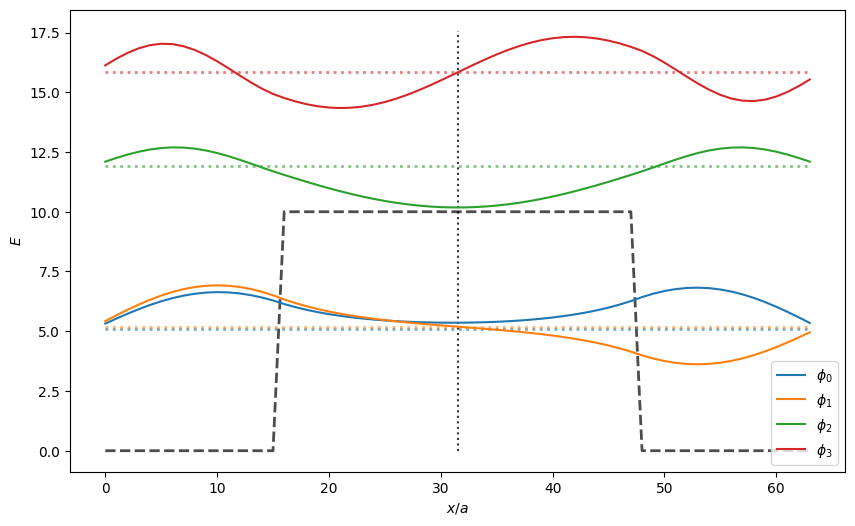

In [956]:
from data_mV import N_points, V0_L, mL, StaticV
tot_eig_val = np.loadtxt('mV_values.txt')
tot_eig_vect = np.loadtxt('mV_vectors.txt')

selec = 4
eig_val = np.copy(tot_eig_val)[:selec]
eig_vect = np.copy(tot_eig_vect)[:, :selec].T

print('Eigenvalues =', eig_val)



xcoo = np.arange(0, N_points)

plt.figure(figsize=(10, 6))
plt.plot(xcoo, StaticV(xcoo), color='black', ls='--', alpha=0.7, 
         lw=2)
for i, eig in enumerate(eig_val):
    plt.hlines(eig, min(xcoo), max(xcoo), color=cols[i], ls=':', alpha=0.6, lw=2)
    plt.plot(xcoo, mL*eig_vect[i] + eig, color=cols[i], zorder=2,
             label=rf'$\phi_{i}$')
    # symmetry
    # plt.plot(np.flip(xcoo), mL*eig_vect[i] + eig, color=cols[i], ls='--', zorder=2)

plt.vlines(xcoo[-1]/2, 0, np.max(eig_vect)*mL+eig_val[-1],
           color='black', ls=':', zorder=0, alpha=0.8)

plt.xlabel(r'$x/a$')
plt.ylabel(r'$E$')
plt.legend(loc='lower right')
plt.show()

## **Ground states**

Eigenvalues = [ -8.59332218 -38.1746     -78.02181193]


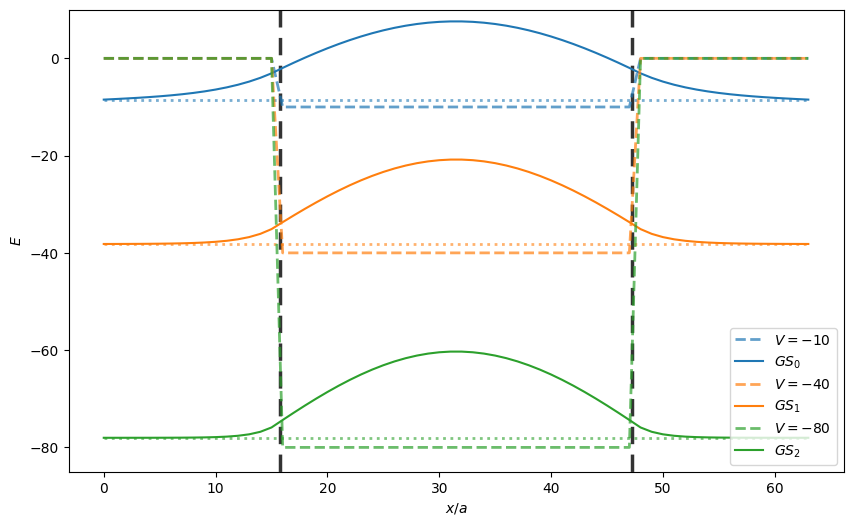

In [957]:

from data_comp import N_points, v_ls, mL
eig_val = np.loadtxt('ground_val.txt')
eig_vect = abs(np.loadtxt('ground_vect.txt'))

print('Eigenvalues =', eig_val)

mL = 75

xcoo = np.arange(0, N_points)

plt.figure(figsize=(10, 6))
for i, eig in enumerate(eig_val):
    def StaticV(x):
        x = np.asarray(x)
        return np.where((x < N_points/4) | (x >= 3/4 * N_points), 0, -v_ls[i])

    plt.plot(xcoo, StaticV(xcoo), color=cols[i], ls='--', alpha=0.7, lw=2,
             label=rf'$V=-{v_ls[i]}$')
    plt.hlines(eig, min(xcoo), max(xcoo), color=cols[i], ls=':', alpha=0.6, lw=2)
    plt.plot(xcoo, mL*eig_vect[i] + eig, color=cols[i], zorder=2,
             label=rf'$GS_{i}$')

bordo = 20
for mul in [1/4, 3/4]:
    plt.vlines(xcoo[-1]*mul, -v_ls[-1]-bordo, bordo,
            color='black', ls=(0, (5, 3)), zorder=0, alpha=0.8, lw=2.5)
plt.ylim(-np.max(v_ls)-5, 10)
plt.xlabel(r'$x/a$')
plt.ylabel(r'$E$')
plt.legend(loc='lower right')
plt.show()

## **Scaling of the eigenvalues**

Eigenvalues =
 [[-8.64377795  5.0123843  24.69871563]
 [-8.62516578  5.29081474 27.32664333]
 [-8.61471514  5.4679779  28.98161923]
 [-8.60827871  5.58996318 30.09608392]
 [-8.6040371   5.67872236 30.88700624]
 [-8.6010942   5.74601658 31.47202349]
 [-8.59896816  5.79868916 31.91932591]
 [-8.59738144  5.84097886 32.27070138]
 [-8.59616515  5.8756442  32.5529705 ]
 [-8.59521171  5.90455392 32.78402866]
 [-8.59445003  5.9290169  32.97621559]
 [-8.59383154  5.94997603 33.13828337]
 [-8.59332218  5.96812708 33.2765928 ]]


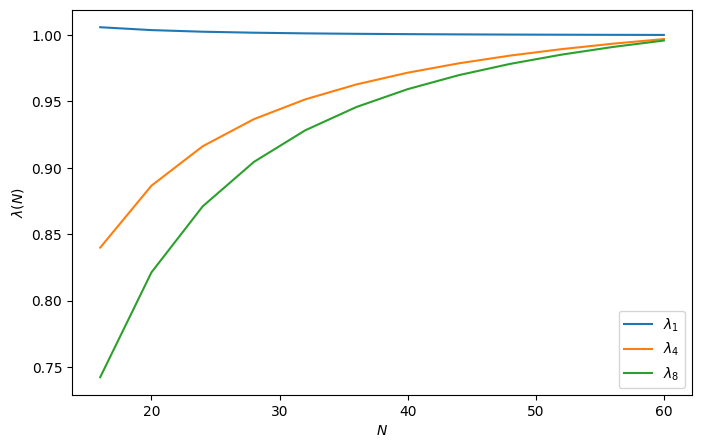

In [958]:

from func_N import N_ls, orders
eig_val = np.loadtxt('scal_N_val.txt')
print('Eigenvalues =\n', eig_val)

eig_i = eig_val[:-1, 0] / eig_val[-1, 0]

plt.figure(figsize=(8,5))
for i in range(3):
    eig_i = eig_val[:-1, i] / eig_val[-1, i]
    plt.plot(N_ls[:-1], eig_i, label=rf'$\lambda_{orders[i]+1}$')


plt.xlabel(r'$N$')
plt.ylabel(r'$\lambda (N)$')
plt.legend(loc='lower right')
plt.show()
